# ROGII Wellbore Geology - Conv1d Hyperparameter Optimization

Find the optimal Dense (MLP) network configuration using **Keras Tuner Hyperband**.

**Features (6):** `MD, X, Y, Z, GR, TVT_input`  
**Label:** `TVT`  
**Backend**: Keras 3 + JAX backend

**Author**: Samir Attrah

In [1]:
"""Environment setup and library imports for hyperparameter optimization of a Dense (MLP) model.

Sets Keras JAX backend and configures JAX precision and allocation behavior.
"""

import os

os.environ["KERAS_BACKEND"] = "jax"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.7"

import jax

# Enable JAX float64 precision natively
jax.config.update("jax_enable_x64", True)

import keras
from keras import callbacks, layers, regularizers
import keras_tuner as kt
import jax.numpy as jnp
import numpy as np
import polars as pl
import glob
import pickle
import random
import warnings

warnings.filterwarnings("ignore")

# Show enough digits to round-trip float64 diagnostics
np.set_printoptions(precision=17, floatmode="unique")

# Set seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Keras backend : {keras.backend.backend()}")
print(f"Working dir   : {os.getcwd()}")


2026-07-21 22:12:45.520858: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1784661165.563533  238028 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1784661165.577289  238028 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Keras version : 3.12.0
Keras backend : jax
Working dir   : /home/samer/Documents/competitions/ROGII/notebooks


### 2. Auto-detect Dataset Path
Locate the competition dataset in local or Kaggle environments.

In [2]:
def find_data_dir():
    """Searches common Kaggle mount points for the ROGII dataset.

    Returns:
        str: Path to the dataset directory containing 'train' subdirectory.

    Raises:
        FileNotFoundError: If the dataset cannot be found in any candidate path.
    """
    candidates = [
        "/kaggle/input/competitions/rogii-wellbore-geology-prediction",
        "/kaggle/input/rogii-wellbore-geology-prediction",
        "/home/samer/Documents/competitions/ROGII/dataset",
    ]

    for scan_root in ["/kaggle/input", "/kaggle/input/competitions"]:
        if os.path.isdir(scan_root):
            for entry in os.listdir(scan_root):
                full = os.path.join(scan_root, entry)
                if os.path.isdir(full) and full not in candidates:
                    candidates.append(full)

    print("Searching for ROGII dataset...")
    for path in candidates:
        if not os.path.isdir(path):
            continue

        contents = os.listdir(path)
        has_train = "train" in contents and os.path.isdir(os.path.join(path, "train"))
        n_train = 0
        if has_train:
            n_train = len(
                glob.glob(os.path.join(path, "train", "*__horizontal_well.csv"))
            )

        if n_train > 0:
            print(f"  V Using {path} (found {n_train} train wells)")
            return path

    raise FileNotFoundError("Could not find ROGII dataset.")


DATA_DIR = find_data_dir()


Searching for ROGII dataset...
  V Using /home/samer/Documents/competitions/ROGII/dataset (found 773 train wells)


### 3. Data helpers & Preparation
Functions for loading well logs, masking `TVT_input` like the test prediction interval, preprocessing with Polars, and standardizing with JAX in float64 precision.

In [3]:
"""Data loading, preprocessing and preparation functions using Polars and JAX.

The dense model is trained with a test-like TVT_input mask. In the competition test
wells, TVT_input is known before the submission interval and missing throughout the
interval that must be predicted. If validation keeps the true TVT_input, the model can
learn an identity shortcut and report unrealistically low validation RMSE.
"""

from typing import Dict, List, Tuple, Union
import glob
import os
import pickle
import jax.numpy as jnp
import numpy as np
import polars as pl

FEATURE_COLS: List[str] = ["MD", "X", "Y", "Z", "GR", "TVT_input"]
TARGET: str = "TVT"
TVT_INPUT_COL: str = "TVT_input"
MASK_START_RATIO_RANGE: Tuple[float, float] = (0.20, 0.40)


def mask_tvt_input_for_prediction_zone(
    df: pl.DataFrame,
    rng: np.random.Generator,
    ratio_range: Tuple[float, float] = MASK_START_RATIO_RANGE,
) -> Tuple[pl.DataFrame, int]:
    """Masks a suffix of TVT_input to mimic the hidden test prediction interval.

    Args:
        df (pl.DataFrame): Input DataFrame containing the well data.
        rng (np.random.Generator): Random number generator for reproducibility.
        ratio_range (Tuple[float, float]): Range of mask start ratio relative
          to well depth.

    Returns:
        Tuple[pl.DataFrame, int]: A tuple containing the masked DataFrame and
          the index where the masking started.
    """
    if TVT_INPUT_COL not in df.columns or len(df) < 2:
        return df, len(df)

    low, high = ratio_range
    mask_start = int(round(len(df) * rng.uniform(low, high)))
    mask_start = min(max(mask_start, 1), len(df) - 1)
    row_nr = pl.int_range(0, pl.len())
    df = df.with_columns(
        pl.when(row_nr >= mask_start)
        .then(None)
        .otherwise(pl.col(TVT_INPUT_COL))
        .alias(TVT_INPUT_COL)
    )
    return df, mask_start


def preprocess(df: pl.DataFrame) -> pl.DataFrame:
    """Interpolates and fills null values in the feature columns.

    Args:
        df (pl.DataFrame): Input DataFrame with missing values.

    Returns:
        pl.DataFrame: Preprocessed DataFrame with all feature columns filled.
    """
    for col in FEATURE_COLS:
        if col in df.columns:
            df = df.with_columns(
                pl.col(col)
                .interpolate()
                .fill_null(strategy="forward")
                .fill_null(strategy="backward")
                .fill_null(0.0)
            )
    return df


def prepare_data(
    data_dir: str,
    val_ratio: float = 0.20,
    seed: int = 42,
    max_wells: Union[int, None] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
    """Loads wells and builds train/validation arrays with test-like masking.

    Reshapes the inputs to 3D tensors compatible with Conv1D layers.

    Args:
        data_dir (str): Path to the training dataset.
        val_ratio (float): Fraction of wells to use for validation.
        seed (int): Random seed for split and masking reproducibility.
        max_wells (Union[int, None]): Maximum number of wells to load (for debugging).

    Returns:
        Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, Dict]:
          A tuple containing:
            - X_train: Preprocessed and standardized training features (3D: [samples, 1, features]).
            - y_train: Standardized training target values (1D: [samples]).
            - X_val: Preprocessed and standardized validation features (3D: [samples, 1, features]).
            - y_val: Standardized validation target values (1D: [samples]).
            - y_val_raw: Raw validation targets in original scale (1D: [samples]).
            - scaler: Dictionary containing standardization scaling parameters.
    """
    dataset_root = os.path.dirname(data_dir)

    # 1. Get original training IDs
    pattern_train = os.path.join(data_dir, "train", "*__horizontal_well.csv")
    files_train = sorted([os.path.basename(f) for f in glob.glob(pattern_train)])

    # 2. Get augmented training files
    pattern_aug = os.path.join(
        dataset_root, "dataset_augmented", "train", "*__horizontal_well_aug.csv"
    )
    files_aug = sorted([os.path.basename(f) for f in glob.glob(pattern_aug)])

    # Combined training file list
    files_train_all = files_train + files_aug

    if max_wells:
        files_train_all = files_train_all[:max_wells]

    rng = np.random.default_rng(seed)
    n_val = max(1, int(len(files_train_all) * val_ratio))
    val_set = set(rng.permutation(len(files_train_all))[:n_val])

    train_files = [fname for i, fname in enumerate(files_train_all) if i not in val_set]
    val_files = [fname for i, fname in enumerate(files_train_all) if i in val_set]

    print(
        f"Loading {len(files_train_all)} training wells total. "
        f"(Original: {len(files_train)}, Augmented: {len(files_aug)})."
    )

    def get_arrays(files: List[str], split_name: str) -> Tuple[np.ndarray, np.ndarray]:
        """Reads CSV files for a split, masks TVT_input, and returns merged arrays.

        Args:
            files (List[str]): List of filenames to load.
            split_name (str): Label for the dataset split (e.g. \"Train\", \"Val\").

        Returns:
            Tuple[np.ndarray, np.ndarray]: Merged features and target arrays.
        """
        feats, tgts, mask_starts = [], [], []
        for filename in files:
            try:
                if filename in files_aug:
                    path = os.path.join(
                        dataset_root, "dataset_augmented", "train", filename
                    )
                else:
                    path = os.path.join(data_dir, "train", filename)

                df = pl.read_csv(path, infer_schema_length=10000)
                df = df.filter(pl.col(TARGET).is_not_null())
                if len(df) == 0:
                    continue

                df, mask_start = mask_tvt_input_for_prediction_zone(df, rng)
                df = preprocess(df)

                feats.append(df.select(FEATURE_COLS).to_numpy().astype(np.float64))
                tgts.append(df.select(TARGET).to_numpy().ravel().astype(np.float64))
                mask_starts.append(mask_start / len(df))
            except Exception as e:
                print(f"  Skip {filename}: {e}")

        if not feats:
            raise ValueError(f"No usable wells found for {split_name} split.")

        print(
            f"{split_name} TVT_input mask start ratio: "
            f"mean={np.mean(mask_starts):.3f}, "
            f"min={np.min(mask_starts):.3f}, max={np.max(mask_starts):.3f}"
        )
        return np.concatenate(feats), np.concatenate(tgts)

    X_train_raw, y_train_raw = get_arrays(train_files, "Train")
    X_val_raw, y_val_raw = get_arrays(val_files, "Val")

    feat_mean = jnp.mean(jnp.array(X_train_raw, dtype=jnp.float64), axis=0)
    feat_std = jnp.std(jnp.array(X_train_raw, dtype=jnp.float64), axis=0)
    feat_std = jnp.where(feat_std == 0, 1.0, feat_std)

    target_mean = jnp.mean(jnp.array(y_train_raw, dtype=jnp.float64))
    target_std = jnp.std(jnp.array(y_train_raw, dtype=jnp.float64))
    target_std = jnp.where(target_std == 0, 1.0, target_std)

    X_train_n = (jnp.array(X_train_raw, dtype=jnp.float64) - feat_mean) / feat_std
    y_train_n = (jnp.array(y_train_raw, dtype=jnp.float64) - target_mean) / target_std
    X_val_n = (jnp.array(X_val_raw, dtype=jnp.float64) - feat_mean) / feat_std
    y_val_n = (jnp.array(y_val_raw, dtype=jnp.float64) - target_mean) / target_std

    scaler = {
        "feature_cols": FEATURE_COLS,
        "feat_mean": np.array(feat_mean),
        "feat_std": np.array(feat_std),
        "target_mean": float(target_mean),
        "target_std": float(target_std),
        "normalized": True,
        "tvt_input_masked_for_training": True,
        "mask_start_ratio_range": MASK_START_RATIO_RANGE,
    }

    # Reshape features to 3D format (samples, sequence_length=1, features) for Conv1D compatibility
    X_train_3d = np.array(X_train_n, dtype=np.float32).reshape(-1, 1, len(FEATURE_COLS))
    X_val_3d = np.array(X_val_n, dtype=np.float32).reshape(-1, 1, len(FEATURE_COLS))

    return (
        X_train_3d,
        np.array(y_train_n, dtype=np.float32),
        X_val_3d,
        np.array(y_val_n, dtype=np.float32),
        y_val_raw,
        scaler,
    )


print("Preparing dataset...")
X_train, y_train, X_val, y_val, y_val_raw, scaler = prepare_data(DATA_DIR)
print(f"Train size: {X_train.shape}, Val size: {X_val.shape}")

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
scaler_path = os.path.join(OUT_DIR, "dense_opt_scaler_params.pkl")
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler parameters saved to {scaler_path}")


Preparing dataset...
Loading 1546 training wells total. (Original: 773, Augmented: 773).
Train TVT_input mask start ratio: mean=0.299, min=0.200, max=0.400
Val TVT_input mask start ratio: mean=0.303, min=0.201, max=0.400
Train size: (7920760, 1, 6), Val size: (1994245, 1, 6)
Scaler parameters saved to ../outputs/dense_opt_scaler_params.pkl


### 4. Define HyperModel & Tuner
Specify the search space for layers count, units, regularization rate, dropout rates, learning rate, and gradient clipping norm using Keras Tuner Hyperband.

In [4]:
class DenseHyperModel(kt.HyperModel):
    """Hyperparameter search space for a 1D Convolutional Neural Network (CNN) model.

    Despite the "Dense" class name (inherited for compatibility), this builds a Conv1D-based
    architecture. It tunes the network depth, convolutional filters, activation functions,
    regularization, dropout, global gradient clipping, and optimizer settings.
    """

    def __init__(self, input_dim: int) -> None:
        """Initializes the hypermodel with input feature dimensions.

        Args:
            input_dim (int): Dimensionality of the input features.
        """
        super().__init__()
        self.input_dim: int = input_dim

    def build(self, hp: kt.HyperParameters) -> keras.Model:
        """Builds and compiles a 1D Conv-based model with tunable hyperparameters.

        Args:
            hp (kt.HyperParameters): Keras Tuner hyperparameter object.

        Returns:
            keras.Model: A compiled Keras Model.
        """
        model = keras.Sequential()
        
        # Expect 3D input of shape (batch, sequence_length=1, features)
        model.add(layers.Input(shape=(1, self.input_dim)))

        # Tune the number of hidden layers
        num_layers: int = hp.Int("num_layers", 2, 6, default=4)

        # Tune activation and initializer globally for all hidden layers
        activation: str = hp.Choice(
            "activation", ["linear", "relu", "selu", "gelu"], default="relu"
        )
        initializer: str = hp.Choice(
            "initializer",
            ["glorot_uniform", "he_normal"],
            default="glorot_uniform",
        )

        for i in range(num_layers):
            units: int = hp.Int(f"units_{i}", 32, 256, step=32, sampling="log", default=128)
            model.add(
                layers.Conv1D(
                    filters=units,
                    kernel_size=hp.Choice(f"kernel_{i}", [3, 5, 7]),
                    activation=activation,
                    kernel_initializer=initializer,
                    kernel_regularizer=regularizers.L2(
                        hp.Float("kr_rate", 1e-6, 1e-3, sampling="log", default=1e-5)
                    ),
                    padding="same",
                )
            )
            # model.add(layers.MaxPooling1D(pool_size=hp.Int("MP", 2, 5, step=1, default=2)))
            dropout_rate: float = hp.Float(f"dropout_{i}", 0.0, 0.4, step=0.1, default=0.2)
            if dropout_rate > 0.0:
                model.add(layers.Dropout(dropout_rate))
        model.add(layers.Flatten())
        model.add(layers.Dense(1, activation="linear"))

        # Optimizer tuning
        optimizer_name: str = hp.Choice(
            "optimizer", ["Adam", "AdamW"], default="Adam"
        )
        lr: float = hp.Float("lr", 5e-5, 5e-2, sampling="log", default=1e-3)

        if optimizer_name == "Adam":
            optimizer = keras.optimizers.Adam(learning_rate=lr)
        elif optimizer_name == "AdamW":
            optimizer = keras.optimizers.AdamW(
                learning_rate=lr,
                weight_decay=hp.Float("weight_decay", 1e-5, 1e-3, sampling="log"),
            )
        else:
            optimizer = keras.optimizers.RMSprop(learning_rate=lr)

        gcn: float = hp.Float("gcn", 0.5, 2.0, step=0.5, default=1.0)

        model.compile(
            optimizer=optimizer,
            loss="mse",
            metrics=[keras.metrics.RootMeanSquaredError(name="rmse")],
        )
        return model


# Initialize the Hyperband tuner
tuner = kt.Hyperband(
    DenseHyperModel(input_dim=len(FEATURE_COLS)),
    objective=kt.Objective("val_rmse", direction="min"),
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory="tuner_results",
    project_name="rogii_dense_opt_norm_augmented_v4",
    overwrite=False,
)

print("Tuner initialized.")
tuner.search_space_summary()


Reloading Tuner from tuner_results/rogii_dense_opt_norm_augmented_v4/tuner0.json
Tuner initialized.
Search space summary
Default search space size: 26
num_layers (Int)
{'default': 4, 'conditions': [], 'min_value': 2, 'max_value': 6, 'step': 1, 'sampling': 'linear'}
activation (Choice)
{'default': 'relu', 'conditions': [], 'values': ['linear', 'relu', 'selu', 'gelu'], 'ordered': False}
initializer (Choice)
{'default': 'glorot_uniform', 'conditions': [], 'values': ['glorot_uniform', 'he_normal'], 'ordered': False}
units_0 (Int)
{'default': 128, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'log'}
kernel_0 (Choice)
{'default': 3, 'conditions': [], 'values': [3, 5, 7], 'ordered': True}
kr_rate (Float)
{'default': 1e-05, 'conditions': [], 'min_value': 1e-06, 'max_value': 0.001, 'step': None, 'sampling': 'log'}
dropout_0 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.0, 'max_value': 0.4, 'step': 0.1, 'sampling': 'linear'}
units_1 (Int)
{'default': 12

### 5. Run Optimization Search
Run Hyperband search with EarlyStopping callback on validation RMSE.

In [5]:
"""Run the hyperparameter tuning search using Hyperband."""

# Increased patience to 10 for more robust evaluation during search
stop_early = callbacks.EarlyStopping(monitor="val_rmse", patience=10)

print("Starting hyperparameter search...")
tuner.search(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    batch_size=256,
    callbacks=[stop_early],
)

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print("\nSearch complete.")


Trial 174 Complete [00h 23m 41s]
val_rmse: 0.11890752613544464

Best val_rmse So Far: 0.052053045481443405
Total elapsed time: 1d 10h 38m 29s

Search complete.


### 6. Retrain Best Model
Rebuild the model with optimal hyperparameters and run full training with checkpoints and early stopping.

In [6]:
"""Build and retrain the model with the best parameters and callbacks."""

# Retrain the model on the full search epochs with early stopping/save checkpoint
model = tuner.hypermodel.build(best_hps)
model.summary()

OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)
best_model_path = os.path.join(OUT_DIR, "optimized_dense_model_augmented.keras")

cbs = [
    callbacks.ModelCheckpoint(
        best_model_path, monitor="val_rmse", save_best_only=True, mode="min"
    ),
    callbacks.ReduceLROnPlateau(
        monitor="val_rmse", factor=0.5, patience=5, min_lr=1e-6
    ),
    callbacks.EarlyStopping(monitor="val_rmse", patience=15, restore_best_weights=True),
]

print("Starting training of the best model...")
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_data=(X_val, y_val),
    batch_size= 128,              #best_hps.get("batch_size"),
    callbacks=cbs,
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 1, 32)          │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 1, 32)          │         7,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,225 (32.13 KB)

 Trainable params: 8,225 (32.13 KB)

 Non-trainable params: 0 (0.00 B)

Starting training of the best model...
Epoch 1/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━ 71s 1ms/step - loss: 0.0214 - rmse: 0.1350 - val_loss: 0.0053 - val_rmse: 0.0585 - learning_rate: 1.4197e-04
Epoch 2/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━ 67s 1ms/step - loss: 0.0120 - rmse: 0.1026 - val_loss: 0.0042 - val_rmse: 0.0544 - learning_rate: 1.4197e-04
Epoch 3/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - loss: 0.0114 - rmse: 0.1019 - val_loss: 0.0041 - val_rmse: 0.0563 - learning_rate: 1.4197e-04
Epoch 4/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - loss: 0.0112 - rmse: 0.1016 - val_loss: 0.0043 - val_rmse: 0.0591 - learning_rate: 1.4197e-04
Epoch 5/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - loss: 0.0111 - rmse: 0.1015 - val_loss: 0.0039 - val_rmse: 0.0558 - learning_rate: 1.4197e-04
Epoch 6/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━ 68s 1ms/step - loss: 0.0110 - rmse: 0.1014 - val_loss: 0.0040 - val_rmse: 0.0579 - learning_rate: 1.4197e-04
Epoch 7/50
61881/61881 ━━━━━━━━━━━━━━━━━━━━

### 7. Evaluate Model (RAW SCALE)
Restore best weights, make predictions on the validation set, and calculate the final validation RMSE in raw scale using JAX math operations.

In [7]:
"""Load the best model and evaluate its final RMSE on raw scale using JAX."""

best_model = keras.saving.load_model(best_model_path)

# Denormalize using JAX
target_mean = jnp.array(scaler["target_mean"], dtype=jnp.float64)
target_std = jnp.array(scaler["target_std"], dtype=jnp.float64)
y_val_raw_jnp = jnp.array(y_val_raw, dtype=jnp.float64)

# Predict on val set (normalized scale)
yp_n = best_model.predict(X_val, batch_size=128).ravel()
yp_n_jnp = jnp.array(yp_n, dtype=jnp.float64)

# Denormalize predictions
yp_jnp = (yp_n_jnp * target_std) + target_mean

# Calculate error and RMSE using JAX
err = yp_jnp - y_val_raw_jnp
rmse = float(jnp.sqrt(jnp.mean(jnp.square(err))))
print(f"\nFinal Val RMSE (Optimized Dense Model, RAW SCALE): {rmse:.4f}")

15581/15581 ━━━━━━━━━━━━━━━━━━━━ 8s 504us/step

Final Val RMSE (Optimized Dense Model, RAW SCALE): 34.1266


### 8. Visualizations
Generate diagnostic plots (training history and predicted vs actual scatter plot) and save them to the `analytics` directory.

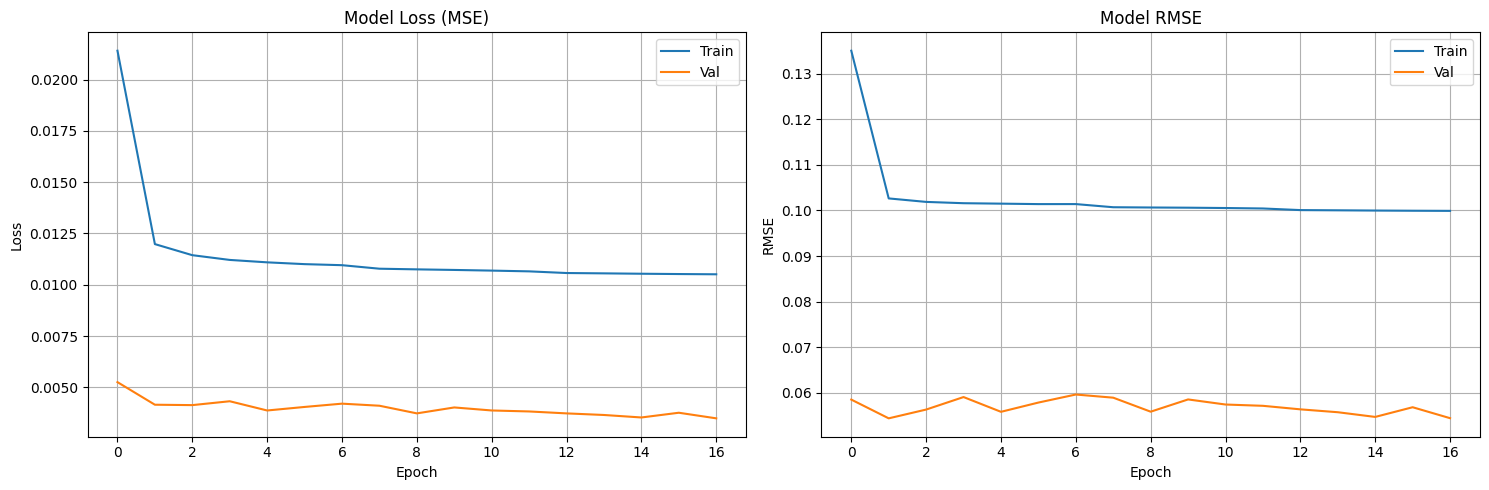

In [8]:
"""Plots training and validation curves and saves them to the analytics directory."""

import matplotlib.pyplot as plt

ANALYTICS_DIR = "../analytics"
os.makedirs(ANALYTICS_DIR, exist_ok=True)


def plot_history(history):
    """Plots model loss and root mean squared error curves.

    Args:
        history: Keras History object.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss curve
    ax1.plot(history.history["loss"], label="Train")
    ax1.plot(history.history["val_loss"], label="Val")
    ax1.set_title("Model Loss (MSE)")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()
    ax1.grid(True)

    # RMSE curve
    ax2.plot(history.history["rmse"], label="Train")
    ax2.plot(history.history["val_rmse"], label="Val")
    ax2.set_title("Model RMSE")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("RMSE")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(ANALYTICS_DIR, "dense_opt_training_history.png"))
    plt.show()


if "history" in locals():
    plot_history(history)

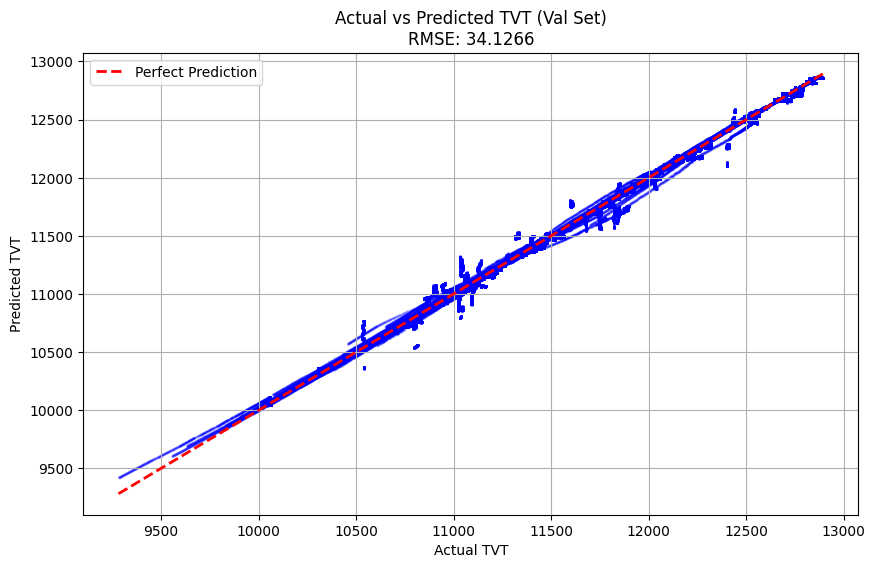

In [9]:
def plot_pred_vs_actual(y_true, y_pred, val_rmse):
    """Plots predicted vs actual values on raw scale and saves it to analytics."""
    plt.figure(figsize=(10, 6))
    plt.scatter(np.array(y_true), np.array(y_pred), alpha=0.1, s=1, color="blue")

    # Draw perfect prediction line
    min_val = min(float(y_true.min()), float(y_pred.min()))
    max_val = max(float(y_true.max()), float(y_pred.max()))
    plt.plot(
        [min_val, max_val], [min_val, max_val], "r--", lw=2, label="Perfect Prediction"
    )

    plt.title(f"Actual vs Predicted TVT (Val Set)\nRMSE: {val_rmse:.4f}")
    plt.xlabel("Actual TVT")
    plt.ylabel("Predicted TVT")
    plt.legend()
    plt.grid(True)

    plt.savefig(os.path.join(ANALYTICS_DIR, "dense_opt_val_pred_vs_actual.png"))
    plt.show()


if "y_val_raw" in locals() and "yp_jnp" in locals():
    plot_pred_vs_actual(y_val_raw, yp_jnp, rmse)